# EMTA andmete analüüs


## Ettevalmistused


In [77]:
from typing import Callable
import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

## Andmetega tutvumine

In [91]:
data_raw_this_year = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv")
data_raw_this_year

C:\Users\jaana\AppData\Local\Temp\ipykernel_23704\2937949000.py:1: DtypeWarning: Columns (0: Registrikood) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw_this_year = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv")


,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,10.04.2026,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,1723565.0,2038192.0,2141341.0,...,1213643.0,1131417.0,34309154.0,30413704.0,23282177.0,21724706.0,254.0,243.0,244.0,240.0
1,10.04.2026,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2026,1561762.0,NaN,NaN,...,NaN,NaN,19993085.0,NaN,NaN,NaN,236.0,NaN,NaN,NaN
2,10.04.2026,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2025,40888.0,41980.0,38723.0,...,38979.0,36127.0,236677.0,235518.0,206299.0,280010.0,11.0,11.0,10.0,10.0
3,10.04.2026,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2026,48644.0,NaN,NaN,...,NaN,NaN,299247.0,NaN,NaN,NaN,11.0,NaN,NaN,NaN
4,10.04.2026,10000062,ALDO KOPPEL,FIE,Ida-Viru ( Lüganuse vald ),"PÕLLUMAJANDUS, METSAMAJANDUS JA KALAPÜÜK",2025,313.0,342.0,635.0,...,0.0,NaN,1941.0,2925.0,9273.0,906.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
428209,10.04.2026,OO000012,HANDELSBOLAGET KORSVÄGEN FÖRVALTING,Mitteresident,NaN,NaN,2025,15.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
428210,10.04.2026,OO000012,HANDELSBOLAGET KORSVÄGEN FÖRVALTING,Mitteresident,NaN,NaN,2026,15.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
428211,10.04.2026,OO000015,TRUST FINANCING AB,Mitteresident,NaN,NaN,2025,136.0,127.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
428212,10.04.2026,QQ000003,RAUMASTER OY,Mitteresident,NaN,HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,37030.0,27615.0,29989.0,...,30725.0,30329.0,20974.0,15075.0,2040.0,42860.0,4.0,4.0,4.0,4.0


In [89]:
duckdb.sql(""" 
    FROM 'tasutud_maksud_varasemad_aastad.csv'
""").df()

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2022,<NA>,288,<NA>,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2023,<NA>,288,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2024,288,52,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,2026-04-10,01834575,"KUNDERI 24, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2024,<NA>,<NA>,268,...,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2022,1300554,1645555,1185273,...,923188,950362,22930261,31976194,26140614,31599227,214,228,231,232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204141,2026-04-10,12556079,STARTUP ESTONIA OÜ,Äriühing,Harju ( Tallinn ),"KUTSE-, TEADUS- JA TEHNIKAALANE TEGEVUS",2022,3022,2076,3223,...,1700,2551,35170,8992,73875,28877,1,1,1,1
204142,2026-04-10,12556079,STARTUP ESTONIA OÜ,Äriühing,Harju ( Tallinn ),"KUTSE-, TEADUS- JA TEHNIKAALANE TEGEVUS",2023,2699,3346,2484,...,1275,1275,15027,5950,13400,14037,1,1,1,1
204143,2026-04-10,12556079,STARTUP ESTONIA OÜ,Äriühing,Harju ( Tallinn ),"KUTSE-, TEADUS- JA TEHNIKAALANE TEGEVUS",2024,1409,5531,1136,...,0,899,7796,22791,5466,9402,1,1,1,1
204144,2026-04-10,12556085,AGRANT OÜ,Äriühing,Harju ( Rae vald ),MAJUTUS JA TOITLUSTUS,2022,781,1277,502,...,0,4981,8095,11406,1251,38735,<NA>,<NA>,1,6


In [45]:
data_raw_new = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv", nrows=5)
data_raw_old = pd.read_csv("tasutud_maksud_varasemad_aastad.csv", nrows=5)
data_raw_new.columns == data_raw_old.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [48]:
data_raw = duckdb.sql(""" 
    --FROM 'tasutud_maksud_kaesolev_aasta.csv'
    --UNION ALL
                      --
    FROM 'tasutud_maksud_varasemad_aastad.csv' 
""").df()
data_raw

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2022,<NA>,288,<NA>,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2023,<NA>,288,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2024,288,52,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,2026-04-10,01834575,"KUNDERI 24, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2024,<NA>,<NA>,268,...,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2022,1300554,1645555,1185273,...,923188,950362,22930261,31976194,26140614,31599227,214,228,231,232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204141,2026-04-10,12556079,STARTUP ESTONIA OÜ,Äriühing,Harju ( Tallinn ),"KUTSE-, TEADUS- JA TEHNIKAALANE TEGEVUS",2022,3022,2076,3223,...,1700,2551,35170,8992,73875,28877,1,1,1,1
204142,2026-04-10,12556079,STARTUP ESTONIA OÜ,Äriühing,Harju ( Tallinn ),"KUTSE-, TEADUS- JA TEHNIKAALANE TEGEVUS",2023,2699,3346,2484,...,1275,1275,15027,5950,13400,14037,1,1,1,1
204143,2026-04-10,12556079,STARTUP ESTONIA OÜ,Äriühing,Harju ( Tallinn ),"KUTSE-, TEADUS- JA TEHNIKAALANE TEGEVUS",2024,1409,5531,1136,...,0,899,7796,22791,5466,9402,1,1,1,1
204144,2026-04-10,12556085,AGRANT OÜ,Äriühing,Harju ( Rae vald ),MAJUTUS JA TOITLUSTUS,2022,781,1277,502,...,0,4981,8095,11406,1251,38735,<NA>,<NA>,1,6


In [49]:
data_raw = duckdb.sql(""" 
    FROM 'tasutud_maksud_kaesolev_aasta.csv'
    UNION ALL
    FROM 'tasutud_maksud_varasemad_aastad.csv' 
""").df()
data_raw

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,1723565,2038192,2141341,...,1213643,1131417,34309154,30413704,23282177,21724706,254,243,244,240
1,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2026,1561762,<NA>,<NA>,...,<NA>,<NA>,19993085,<NA>,<NA>,<NA>,236,<NA>,<NA>,<NA>
2,2026-04-10,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2025,40888,41980,38723,...,38979,36127,236677,235518,206299,280010,11,11,10,10
3,2026-04-10,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2026,48644,<NA>,<NA>,...,<NA>,<NA>,299247,<NA>,<NA>,<NA>,11,<NA>,<NA>,<NA>
4,2026-04-10,10000062,ALDO KOPPEL,FIE,Ida-Viru ( Lüganuse vald ),"PÕLLUMAJANDUS, METSAMAJANDUS JA KALAPÜÜK",2025,313,342,635,...,0,<NA>,1941,2925,9273,906,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632355,2026-04-10,12556079,STARTUP ESTONIA OÜ,Äriühing,Harju ( Tallinn ),"KUTSE-, TEADUS- JA TEHNIKAALANE TEGEVUS",2022,3022,2076,3223,...,1700,2551,35170,8992,73875,28877,1,1,1,1
632356,2026-04-10,12556079,STARTUP ESTONIA OÜ,Äriühing,Harju ( Tallinn ),"KUTSE-, TEADUS- JA TEHNIKAALANE TEGEVUS",2023,2699,3346,2484,...,1275,1275,15027,5950,13400,14037,1,1,1,1
632357,2026-04-10,12556079,STARTUP ESTONIA OÜ,Äriühing,Harju ( Tallinn ),"KUTSE-, TEADUS- JA TEHNIKAALANE TEGEVUS",2024,1409,5531,1136,...,0,899,7796,22791,5466,9402,1,1,1,1
632358,2026-04-10,12556085,AGRANT OÜ,Äriühing,Harju ( Rae vald ),MAJUTUS JA TOITLUSTUS,2022,781,1277,502,...,0,4981,8095,11406,1251,38735,<NA>,<NA>,1,6


In [56]:
data_unpivot = duckdb.sql("""
WITH base AS (
    SELECT
        "Andmete seis",
        "Registrikood",
        "Nimi",
        "Liik",
        "Maakond",
        "Tegevusala",
        "Aasta",
        "Riiklikud maksud I kv" AS riiklikud_maksud_1,
        "Riiklikud maksud II kv" AS riiklikud_maksud_2,
        "Riiklikud maksud III kv" AS riiklikud_maksud_3,
        "Riiklikud maksud IV kv" AS riiklikud_maksud_4,
        "Tööjõumaksud I kv" AS toojou_maksud_1,
        "Tööjõumaksud II kv" AS toojou_maksud_2,
        "Tööjõumaksud III kv" AS toojou_maksud_3,
        "Tööjõumaksud IV kv" AS toojou_maksud_4,
        "Käive I kv" AS kaive_1,
        "Käive II kv" AS kaive_2,
        "Käive III kv" AS kaive_3,
        "Käive IV kv" AS kaive_4,
        "Töötajate arv I kv" AS tootajad_1,
        "Töötajate arv II kv" AS tootajad_2,
        "Töötajate arv III kv" AS tootajad_3,
        "Töötajate arv IV kv" AS tootajad_4
    FROM data_raw
)
UNPIVOT base
ON
    (riiklikud_maksud_1, toojou_maksud_1, kaive_1, tootajad_1),
    (riiklikud_maksud_2, toojou_maksud_2, kaive_2, tootajad_2),
    (riiklikud_maksud_3, toojou_maksud_3, kaive_3, tootajad_3),
    (riiklikud_maksud_4, toojou_maksud_4, kaive_4, tootajad_4)
INTO
    NAME kvartal
    VALUE riiklikud_maksud, toojoumaksud, kaive, tootajate_arv;
""")
data_unpivot

┌─────────────────────┬──────────────┬─────────────────────────┬──────────┬─────────────────────────────┬─────────────────────────────────────────────────────────────────┬───────┬───────────────────────────────────────────────────────┬──────────────────┬──────────────┬──────────┬───────────────┐
│    Andmete seis     │ Registrikood │          Nimi           │   Liik   │           Maakond           │                           Tegevusala                            │ Aasta │                        kvartal                        │ riiklikud_maksud │ toojoumaksud │  kaive   │ tootajate_arv │
│      timestamp      │   varchar    │         varchar         │ varchar  │           varchar           │                             varchar                             │ int64 │                        varchar                        │      int64       │    int64     │  int64   │     int64     │
├─────────────────────┼──────────────┼─────────────────────────┼──────────┼─────────────────────────────┼────

In [120]:
def eralda_maakond(maakond: str) -> str:
    return maakond.split(" ( ") [0]

def eralda_kov(maakond: str) -> str:
    return maakond.split(" ( ") [1][:-2]

def puhasta_kvartal(kvartal: str) -> int:
    return int(kvartal[-1])

def peamine_tegevusala(tegevusala: str) -> str:
    return tegevusala.split(";")[0]


def _register_duckdb_function(duckdb_function_name: str, function: Callable) -> None:
    try:
        duckdb.remove_function(duckdb_function_name)
    except:
        pass
    duckdb.create_function(duckdb_function_name, function)

_register_duckdb_function("eralda_maakond", eralda_maakond)
_register_duckdb_function("eralda_kov", eralda_kov)
_register_duckdb_function("puhasta_kvartal", puhasta_kvartal)
_register_duckdb_function("peamine_tegevusala", peamine_tegevusala)



In [121]:
data = duckdb.sql(""" 
    SELECT
      Registrikood AS registrikood,
      Nimi as nimi,
      Liik as liik,
      eralda_maakond(Maakond) AS maakond,
      eralda_kov(Maakond) AS kov,
      peamine_tegevusala(Tegevusala) AS tegevusala,
      Aasta AS aasta,
      puhasta_kvartal(kvartal) AS kvartal,
      riiklikud_maksud,
      toojoumaksud,
      kaive,
      tootajate_arv
  FROM data_unpivot
           
""").df()
data

,registrikood,nimi,liik,maakond,kov,tegevusala,aasta,kvartal,riiklikud_maksud,toojoumaksud,kaive,tootajate_arv
0,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,1,1723565,1259900,34309154,254
1,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,2,2038192,1229742,30413704,243
2,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,3,2141341,1213643,23282177,244
3,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,4,1844403,1131417,21724706,240
4,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2026,1,1561762,1088007,19993085,236
...,...,...,...,...,...,...,...,...,...,...,...,...
662267,12556085,AGRANT OÜ,Äriühing,Harju,Rae vald,MAJUTUS JA TOITLUSTUS,2022,4,8590,4981,38735,6
662268,12556085,AGRANT OÜ,Äriühing,Harju,Rae vald,MAJUTUS JA TOITLUSTUS,2023,1,10907,7667,70520,7
662269,12556085,AGRANT OÜ,Äriühing,Harju,Rae vald,MAJUTUS JA TOITLUSTUS,2023,2,11307,6160,72468,8
662270,12556085,AGRANT OÜ,Äriühing,Harju,Rae vald,MAJUTUS JA TOITLUSTUS,2023,3,21433,13274,121259,6


## Avastuslik andmeanalüüs *(exploratory analysis)*

In [92]:
duckdb.sql("""
    SUMMARIZE data
""")

┌──────────────────┬─────────────┬──────────────────────────────────────────────────────────────┬────────────────────┬───────────────┬────────────────────┬────────────────────┬─────────┬─────────┬─────────┬────────┬─────────────────┐
│   column_name    │ column_type │                             min                              │        max         │ approx_unique │        avg         │        std         │   q25   │   q50   │   q75   │ count  │ null_percentage │
│     varchar      │   varchar   │                           varchar                            │      varchar       │     int64     │      varchar       │      varchar       │ varchar │ varchar │ varchar │ int64  │  decimal(9,2)   │
├──────────────────┼─────────────┼──────────────────────────────────────────────────────────────┼────────────────────┼───────────────┼────────────────────┼────────────────────┼─────────┼─────────┼─────────┼────────┼─────────────────┤
│ registrikood     │ VARCHAR     │ 10000018                     

In [102]:
duckdb.sql("""
    SELECT
           maakond,
           count(DISTINCT registrikood) AS ettevotete_arv,
           ROUND(AVG(kaive) / 3)::int AS kvartaalne_kuine_kaive,
           ROUND(AVG(kaive))::int AS keskmine_kvartaalne_kaive
    FROM data
    WHERE aasta = 2026 AND kvartal = 1
    GROUP BY maakond
    ORDER BY keskmine_kvartaalne_kaive DESC
""")

┌────────────┬────────────────┬────────────────────────┬───────────────────────────┐
│  maakond   │ ettevotete_arv │ kvartaalne_kuine_kaive │ keskmine_kvartaalne_kaive │
│  varchar   │     int64      │         int32          │           int32           │
├────────────┼────────────────┼────────────────────────┼───────────────────────────┤
│ NULL       │            141 │                 254183 │                    762548 │
│ Harju      │          31202 │                 201933 │                    605799 │
│ Järva      │            936 │                 124710 │                    374131 │
│ Tartu      │           6616 │                 120512 │                    361536 │
│ Lääne-Viru │           2095 │                 105897 │                    317690 │
│ Viljandi   │           1723 │                  88801 │                    266402 │
│ Valga      │            839 │                  81555 │                    244664 │
│ Jõgeva     │            949 │                  80395 │         

<Axes: xlabel='tootajate_arv', ylabel='tegevusala'>

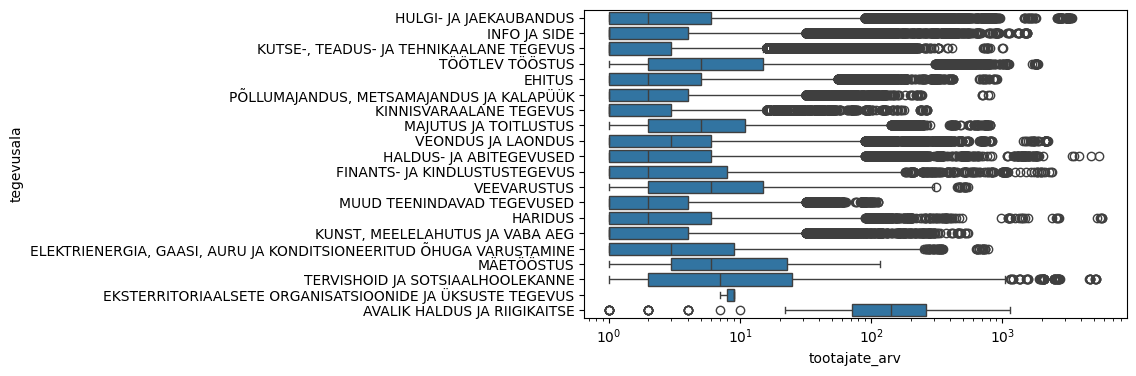

In [131]:
plt.figure(1, figsize=(7,4))
sns.boxplot(data, x="tootajate_arv", y="tegevusala", log_scale=10)
# ax.set_xscale('log')

In [132]:
data.to_csv("emta_data.csv", index=False)